# Phasor method for Bi-exponential FLI Data processing

A simulated, full 3-D fluorescence lifetime image dataset of a two-well plate is generated (using the same simulator as the "Whole Image Simulation" example), and the phasor method is used to process the data. Each well is assigned a different set of lifetime / FRET parameters.

This example walks through:
- Simulating the two-well FLI data
- The phasor computation
- Phasor calibration with the IRF (if a known dye is used, it can also be used for calibration here — not shown in this example)
- 3-harmonics computation
- Phasor plot (with pixel counts)
- Mapping phasor color to pixel color (pixel-wise phasor overlay) and pixel-wise, intensity-weighted phasor color overlay
- Phasor lifetime computation
- Phasor plot of different harmonics
- Curve fitting and fraction computation (based on user-provided lifetime values)

<small>Author - Vikas</small>


In [ ]:
## importing the modules required for this work
import sys

import numpy as np

sys.path.insert(0, "ex_helper")  # local helper for synthetic image generation

from sim_general_image import ROIMaskGenerator

from pyfli.analysis.utils import random_true_pixel
from pyfli.analyticalWorkflow import AnalyticalHelpers
from pyfli.data_cc import Normalization
from pyfli.data_text import MessageDisplay
from pyfli.data_vnp import ColorProcessor, DataViewer
from pyfli.io import DataOperations
from pyfli.phasor.phasorS import PhasorAnalyzer
from pyfli.simulator import FLIModelImageGenerator

In [3]:
# Path to the local IRF file (e.g. an SPCImage-exported .txt calibration file)
IRF_PATH = "<select file/folder path>"

In [4]:
loader = DataOperations(irf_path=IRF_PATH)
irf_data = loader.load_irf()

gate_delay = 12.5 / irf_data.shape[2]
num_gates = irf_data.shape[2]
freq = AnalyticalHelpers(
    laser_period=12.5, gate_delay=gate_delay, num_gate=num_gates
).freq_computation()

INFO:pyfli:Initiating IRF load from: <select file/folder path>


In [ ]:
# select the type of decay model to simulate
MODEL_TYPE = "bi-exponential"
if MODEL_TYPE == "bi-exponential":
    mono_fraction = 0.0
elif MODEL_TYPE == "mono-exponential":
    mono_fraction = 1.0
else:
    mono_fraction = 0.4  # fraction of mono-exponential model in sampled data

# Your constant, default configuration
BASE_CONFIG = {
    # Modular Noise
    "jitter": False,  # offset artifact (due to jitter)
    "dcr_on": True,  # Dark Count Rate (thermal background)
    "poisson": False,  # Shot noise — Large detector only
    "qe_on": True,  # Quantum efficiency scaling
    "read_noise_on": False,  # Gaussian read noise — Large detector only
    # Sensor
    "sensor_type": "discrete",  # "continuous" | "discrete"
    "bit": 12,
    "dcr": 0.08,  # Mean dark counts per bin
    "laser_feq": freq[1],  # Laser repetition rate (MHz) → period = 12.5 ns
    "round_on": True,  # Round photon counts to integers — Macro_sim only
    "clip_on": True,  # Clip at bit-depth ceiling — Macro_sim: max_adc_val; TCSPC: max_bin_count
    # Fluorescence Physics (FLI / FRET)
    "tau2": (1, 1),  # τ₂ ~ TruncNormal(mu=1 ns, sigma=0.5 ns)
    "tau2_dist": "beta",  # if dist "beta" or "normal" (default)
    "tau2_beta_range": (2.5, 0.1),
    "efficiency": (1, 1),  # FRET efficiency E ~ Beta(2, 5)  → [0.1, 1.0]
    "A1_fraction": (1, 1),  # Amplitude fraction A₁ ~ Beta(2, 5) → [0.05, 0.95]
    "photo_count": (2, 5),  # Peak intensity ~ Beta(2, 5) × max_adc - large detectors
    "mono_fraction": mono_fraction,  # Fraction of pixels forced mono-exponential (0.0 = all bi-exp)
    "n_cycles": (1_500_000, 2_000_000),  # Accumulation cycles — for photon counter
}

In [ ]:
def get_config(**kwargs):
    """Create a config by overriding defaults with specific test parameters."""
    config = BASE_CONFIG.copy()
    config.update(kwargs)
    return config


In [ ]:
# Shared plotting / phasor configuration used by the two-well example below
colorset = "rainbow"
freq_hz = freq[1] * 1e6
jet_m_well = ColorProcessor().lowest_zero("jet")
bg_color = "black"  # either "black" or "white"
ph_cols_ = "viridis_r"


## Two wells example

A two-well plate is simulated, with each well assigned a different set of ground-truth lifetime / FRET parameters.

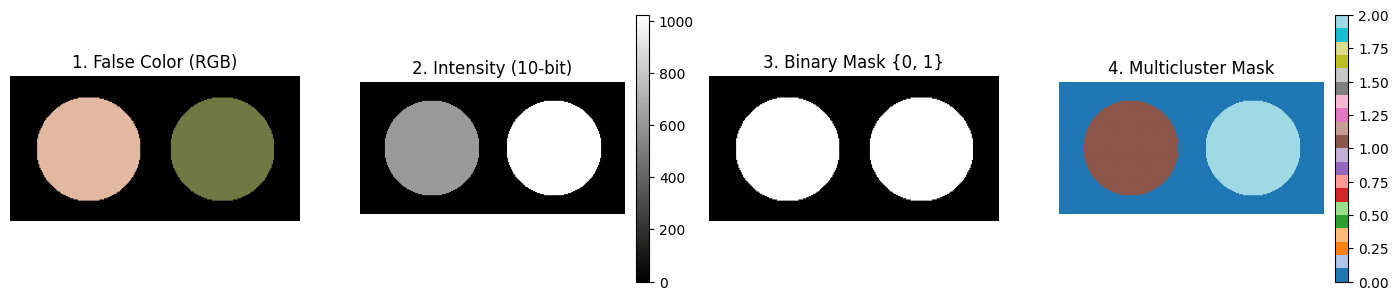

In [30]:
from sim_general_image import WellPlateShape

h_well, w_well = 128, 256
generator_well = ROIMaskGenerator((h_well, w_well), top=10, bottom=10, left=10, right=10)
TwoWells = WellPlateShape(rows=1, cols=2, gap=0.15)

custom_intensities_well = [ 0.6, 1.0]
_ = generator_well.plot_preview(
    TwoWells,
    bit_depth=10,
    intensities=custom_intensities_well,
    show=True,
)

In [38]:
ROI0_well = {}
ROI1_well = get_config(
    tau2_beta_range=(0.1, 1.8),
    efficiency = (50, 2),  
    A1_fraction = (7, 13),
)
ROI2_well = get_config(
    tau2_beta_range=(0.05, 0.8),
    efficiency = (1000, 1000),  
    A1_fraction = (15, 5),
)

In [39]:
img_intensity_well = generator_well.generate_intensity_image(
    TwoWells, intensities=custom_intensities_well
)
img_cluster_well = generator_well.generate_cluster_mask(TwoWells)
b_bool_mask_well = generator_well.generate_binary_mask(TwoWells)

simulated_img_well = FLIModelImageGenerator(
    irf_data=irf_data[120, 40, :],
    intensity_image=img_intensity_well,
    roi_mask=img_cluster_well,
    roi_params=[ROI0_well, ROI1_well, ROI2_well],
    method="PHOTON_COUNTER",
    verbose=True,
    bool_mask=b_bool_mask_well,
)

gt_data_well = simulated_img_well.generate_image()

INFO:pyfli:Generating PHOTON_COUNTER FLI Image [128x256x256]...


Check the decay, IRF, and fit at a randomly selected pixel.

the non-zero pixel selected for probing is (78, 64)


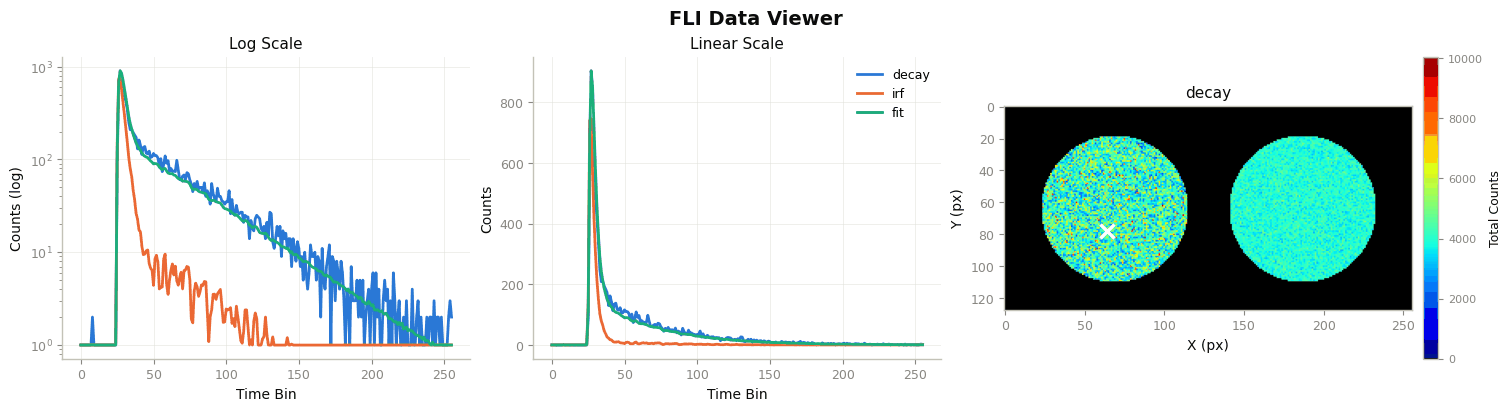

INFO:pyfli:
  Pixel (78, 64)
  ─────────────────────
  A         11175.6943
  α         0.3627
  τ₁        0.0493
  τ₂        1.8539
  R²        —
  Red.χ²    —
  Raw.χ²    —
  v-shift   0.0000
  h-shift   —
  ─────────────────────



In [41]:
_decay_well = gt_data_well["raw_data"]["decay"]
_irf_well = gt_data_well["raw_data"]["irf"]
x_well, y_well = random_true_pixel(b_bool_mask_well)
TRs_well = gt_data_well["results"]["TR_maps"]
maps_well = gt_data_well["results"]["maps"]
print(f"the non-zero pixel selected for probing is ({x_well}, {y_well})")
irf_norm_well = Normalization(_irf_well).norm_scale(_decay_well)
DataViewer().plot_fli_px(
    data_list=[_decay_well, irf_norm_well, TRs_well["fit_map"], TRs_well["residual_map"]],
    pixel=(x_well, y_well),
    mode=[0, 1, 2],
    mode2=[1],
    names=["decay", "irf", "fit"],
    cmap=jet_m_well,
)
_ = MessageDisplay().get_pixel_summary(data_maps=maps_well, px=(x_well, y_well))

Distribution of the simulated ground-truth parameters across the image, before computing phasors.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

res_well = gt_data_well["results"]["maps"]

b_bool_mask_well_bool = b_bool_mask_well.astype(bool)
valid_px_well = np.argwhere(b_bool_mask_well)
rng_well = np.random.default_rng(0)
sample_idx_well = rng_well.choice(len(valid_px_well), size=min(300, len(valid_px_well)), replace=False)
sample_px_well = valid_px_well[sample_idx_well]
decay_sample_well = _decay_well[sample_px_well[:, 0], sample_px_well[:, 1], :]
irf_sample_well = _irf_well[sample_px_well[:, 0], sample_px_well[:, 1], :]
photon_count_sample_well = res_well["photon_count_map"][sample_px_well[:, 0], sample_px_well[:, 1]]

tau1_valid_well = res_well["tau1_map"][b_bool_mask_well_bool]
tau2_valid_well = res_well["tau2_map"][b_bool_mask_well_bool]
alpha1_valid_well = res_well["alpha1_map"][b_bool_mask_well_bool]
tau_mean_valid_well = res_well["tau_mean_map"][b_bool_mask_well_bool]
efficiency_valid_well = res_well["fret_efficiency_map"][b_bool_mask_well_bool]
photon_count_valid_well = res_well["photon_count_map"][b_bool_mask_well_bool]
tau_dif_well = tau2_valid_well - tau1_valid_well

fig, axes = plt.subplots(2, 5, figsize=(15, 8))

axes[0, 0].plot(decay_sample_well.T)
axes[0, 0].set_title("decay")
axes[0, 0].set_xlabel("bins")
axes[0, 0].set_ylabel("Photon Counts")

axes[0, 1].plot((irf_sample_well * photon_count_sample_well[:, None]).T)
axes[0, 1].set_title("irf * photon_count")
axes[0, 1].set_xlabel("bins")
axes[0, 1].set_ylabel("Photon Counts")

sns.histplot(data=tau_mean_valid_well, ax=axes[0, 2], kde=True, stat="density", color="tab:orange", alpha=0.4)
axes[0, 2].set_title("mean tau")
axes[0, 2].set_xlabel("Lifetime (ns)")

sns.histplot(data=tau_dif_well, ax=axes[0, 3], kde=True, stat="density", color="tab:orange", alpha=0.4)
axes[0, 3].set_title("Δ tau")
axes[0, 3].set_xlabel("Lifetime (ns)")

sns.histplot(data=efficiency_valid_well, ax=axes[0, 4], kde=True, stat="density", color="tab:green", alpha=0.4)
axes[0, 4].set_title("FRET Efficiency")
axes[0, 4].set_xlabel("Efficiency")

sns.histplot(data=tau1_valid_well, ax=axes[1, 0], kde=True, stat="density", color="tab:green", alpha=0.4)
axes[1, 0].set_title("tau1")
axes[1, 0].set_xlabel("Lifetime (ns)")

sns.histplot(data=tau2_valid_well, ax=axes[1, 1], kde=True, stat="density", color="tab:red", alpha=0.4)
axes[1, 1].set_title("tau2")
axes[1, 1].set_xlabel("Lifetime (ns)")

sns.histplot(data=alpha1_valid_well, ax=axes[1, 2], kde=True, stat="density", color="tab:purple", alpha=0.4)
axes[1, 2].set_title("alpha1")
axes[1, 2].set_xlabel("Amplitude Fraction")
axes[1, 2].set_xlim(0.0, 1.0)

axes[1, 3].scatter(tau_dif_well, alpha1_valid_well, s=8, alpha=0.3)
axes[1, 3].set_xlabel("Δ tau")
axes[1, 3].set_ylabel("fraction")

sns.histplot(data=photon_count_valid_well, ax=axes[1, 4], kde=True, stat="density", color="tab:purple", alpha=0.4)
axes[1, 4].set_title("photon_count")
axes[1, 4].set_xlabel("photons")

plt.tight_layout()
plt.show()

### Phasor computation and visualization

In [43]:
time_axis_ns_well = np.linspace(0, gate_delay * num_gates, _irf_well.shape[2])
phasor_well = PhasorAnalyzer(
    frequency_hz=freq_hz, time_axis_ns=time_axis_ns_well, n_harmonics=3
)
G_well, S_well = phasor_well.create_phasor_gpu(_decay_well)
Gc_well, Sc_well = phasor_well.calibrate_pixelwise(G_well, S_well, _irf_well)
tau_map_ns_well = phasor_well.compute_lifetime(Gc_well[0], Sc_well[0])

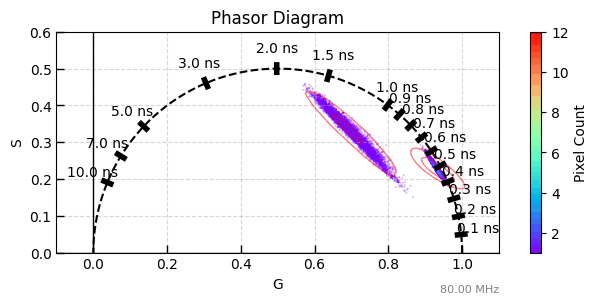

In [44]:
im1_well = phasor_well.plot_phasor_diagram(
    Gc_well[0],
    Sc_well[0],
    mask=b_bool_mask_well,
    hexbin_color=colorset,
    figsize=(7, 3),
    half_circle=True,
    kdeplot=True,
    kde_color="red",
    kde_levels=3,
    kde_linewidths=1,
    kde_alpha=0.5,
)

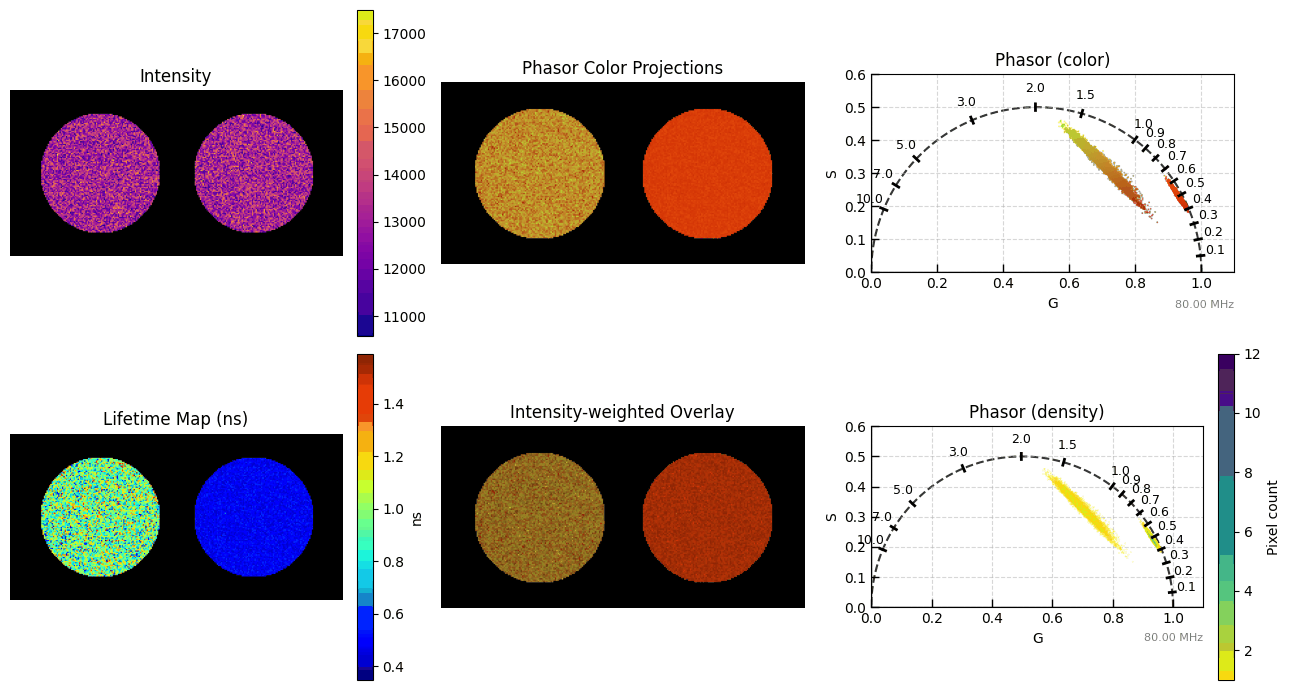

In [45]:
im2_well = phasor_well.plot_overlay_subplots(
    _decay_well,
    Gc_well[0],
    Sc_well[0],
    mask=b_bool_mask_well,
    colormaps=["plasma", "jet", "turbo_r", ph_cols_],
    figsize=(13, 7),
    xlim=(0, 1.1),
    bg_color=bg_color,
    transpose=False,
    kdeplot=False,
)

## Additional steps to plot different harmonics

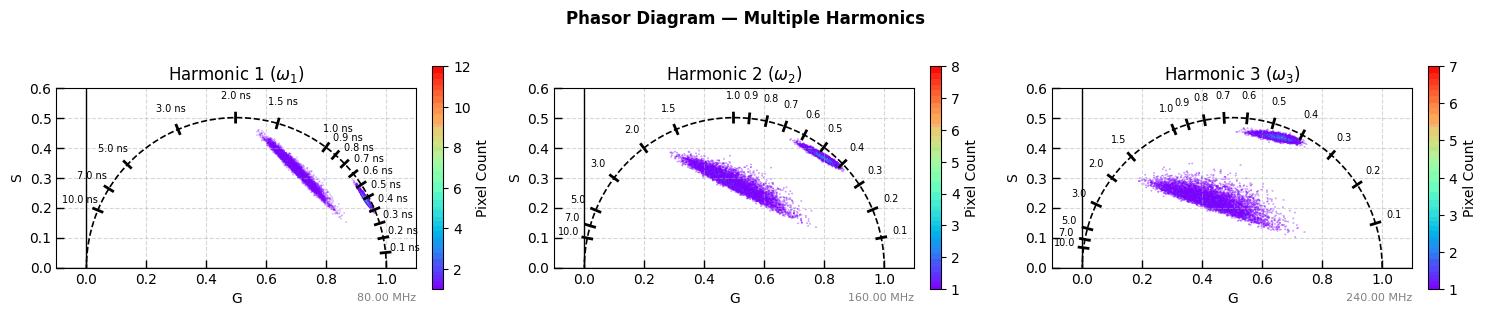

In [46]:
im3_well = phasor_well.plot_phasor_harmonics(
    Gc_well,
    Sc_well,
    harmonics=(1, 2, 3),
    mask=b_bool_mask_well,
    hexbin_color=colorset,
    figsize=(15, 3),
)

### Phasor of fitting based on the guessed lifetime

Selecting the mono-exponential model for reconstructing the fit generates a general set of fit values.

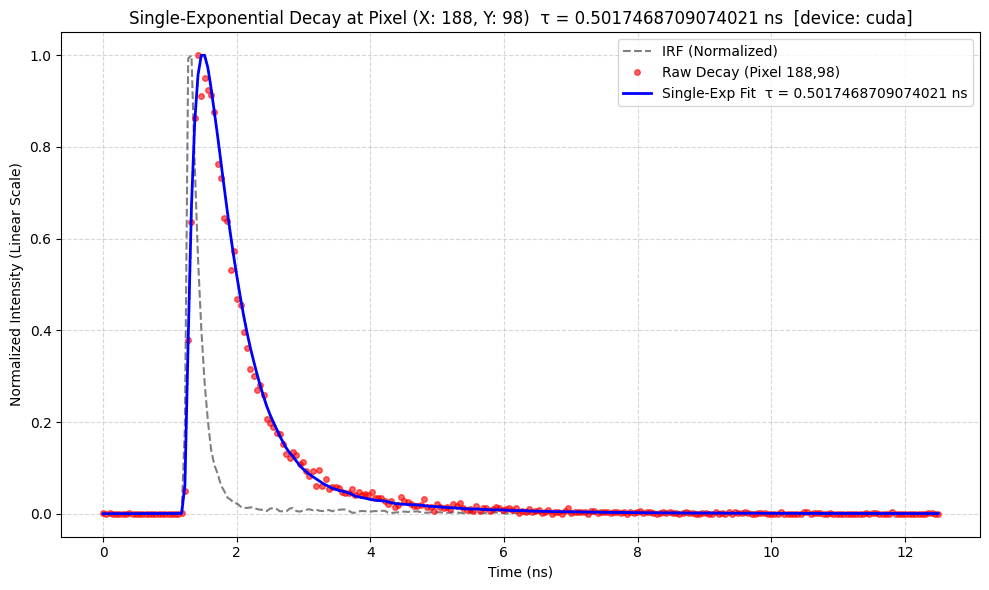

In [53]:
x_well, y_well = random_true_pixel(b_bool_mask_well)
fitting_type_well = "mono-exponential"  # "mono-exponential" or "bi-exponential"

if fitting_type_well == "mono-exponential":
    tau_ns_well = 0.8
    phasor_well.plot_pixel_fit_single_exp(
        _irf_well, _decay_well, tau_map_ns_well, y_well, x_well, log_scale=False
    )
else:
    tau1_ns_well, tau2_ns_well = 0.8, 1.4
    A1_well, A2_well = phasor_well.compute_fractions(
        Gc_well[0], Sc_well[0], tau1_ns_well, tau2_ns_well
    )
    reconstructed_decay_well = phasor_well.analyze_biexponential_and_reconstruct(
        Gc_well[0], Sc_well[0], _irf_well, tau1_ns=tau1_ns_well, tau2_ns=tau2_ns_well, plot=True
    )
    print(f"Reconstructed decay shape: {reconstructed_decay_well.shape}")
    phasor_well.plot_pixel_fit(
        _irf_well, _decay_well, reconstructed_decay_well, y_well, x_well, log_scale=False
    )

Selecting the bi-exponential model for reconstructing the fit generates a general set of fit values.

Reconstructed decay shape: (128, 256, 256)


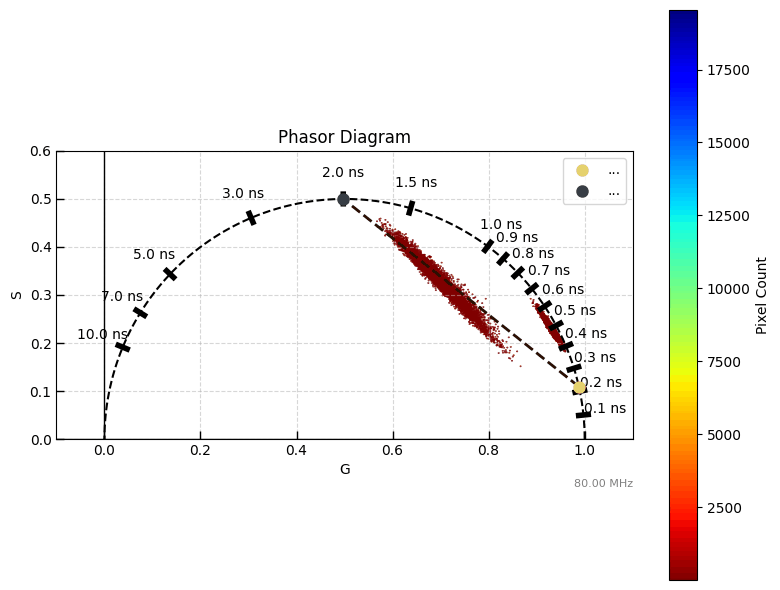

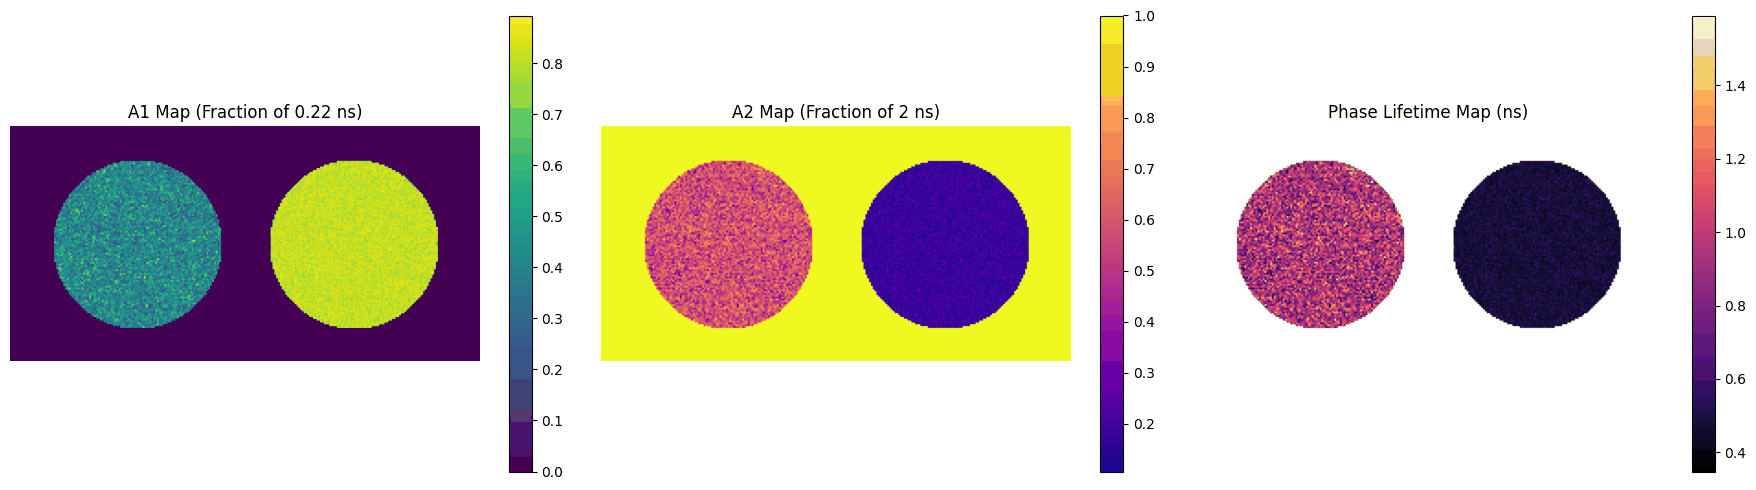

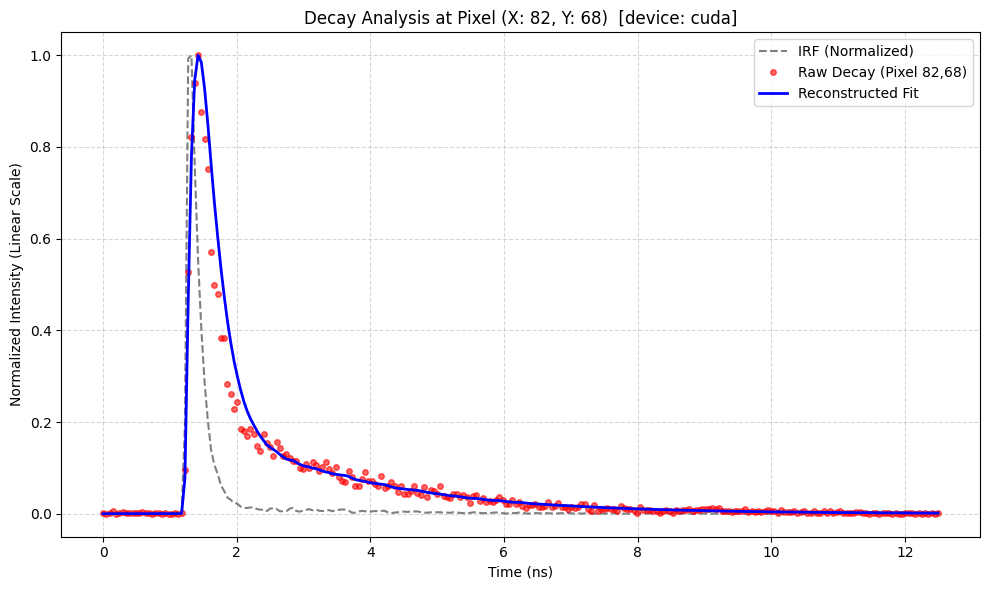

In [54]:
x_well, y_well = random_true_pixel(b_bool_mask_well)
fitting_type_well = "bi-exponential"  # "mono-exponential" or "bi-exponential"

if fitting_type_well == "mono-exponential":
    tau_ns_well = 1.0
    phasor_well.plot_pixel_fit_single_exp(
        _irf_well, _decay_well, tau_map_ns_well, y_well, x_well, log_scale=False
    )
else:
    tau1_ns_well, tau2_ns_well = 0.22, 2
    A1_well, A2_well = phasor_well.compute_fractions(
        Gc_well[0], Sc_well[0], tau1_ns_well, tau2_ns_well
    )
    reconstructed_decay_well = phasor_well.analyze_biexponential_and_reconstruct(
        Gc_well[0], Sc_well[0], _irf_well, tau1_ns=tau1_ns_well, tau2_ns=tau2_ns_well, plot=True
    )
    print(f"Reconstructed decay shape: {reconstructed_decay_well.shape}")
    phasor_well.plot_pixel_fit(
        _irf_well, _decay_well, reconstructed_decay_well, y_well, x_well, log_scale=False
    )